$$\Huge{\text{Learning Simulations}}$$

In [13]:
%autoreload 2

import numpy as np
import networkx as nx
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
mpl.rcParams['text.usetex'] = True

from tqdm.notebook import tqdm

from slim.model import SLIM
from slim.utils import *
from slim import viz

---

# Learning Stationary World Dynamics

---

### Generate Sequences

In [2]:
deterministic_sequence = np.array([0, 1, 2]*30)
dim = len(np.unique(deterministic_sequence))

stochastic_dynamics_matrix = np.array([[.1,.8,.1],
                                       [.1,.1,.8],
                                       [.8,.1,.1]])
x = 0
stochastic_sequence = [x]
for i in range(len(deterministic_sequence)-1):
    x = np.random.choice(np.arange(0,3), p=stochastic_dynamics_matrix[x])
    stochastic_sequence.append(x)

### Define Sensors

In [3]:
sensor = sensor_eye(dim)
noisy_sensor = sensor_eye(dim, gaussian={'sigma': 0.3, 'mode': 'reflect'})
very_noisy_sensor = sensor_eye(dim, gaussian={'sigma': 0.5, 'mode': 'reflect'})

### Fit Models

In [4]:
learning_rate = .1

# model definitions
low = SLIM(order=1, dim=dim, model_name='No Noise')
low_sensor_noise = SLIM(order=1, dim=dim, model_name='Low Noise')
low_process_noise = SLIM(order=1, dim=dim, model_name='No Noise')
low_then_sensor_off = SLIM(order=1, dim=dim, model_name=r'Low Noise $\rightarrow$ Sensor Off')

low_process_and_sensor_noise = SLIM(order=1, dim=dim, model_name='Low Noise')
high_sensor_noise = SLIM(order=1, dim=dim, model_name='High Noise')
high_process_and_sensor_noise = SLIM(order=1, dim=dim, model_name='High Noise')
low_process_then_sensor_off = SLIM(order=1, dim=dim, model_name=r'Low Noise $\rightarrow$ Sensor Off')

loop = tqdm(range(0, len(deterministic_sequence)))
for t in loop:
    # print(f'-------------------------------- t={t} --------------------------------')
    h = sensor[deterministic_sequence[t]]
    low.step(h, learning_rate=learning_rate)

    h_sensor_noise = noisy_sensor[deterministic_sequence[t]]
    low_sensor_noise.step(h_sensor_noise, learning_rate=learning_rate)
    
    if t < len(deterministic_sequence)//2:
        low_then_sensor_off.step(h_sensor_noise, learning_rate=learning_rate)
    else:
        low_then_sensor_off.step(np.ones(3, dtype=np.float16)/3, learning_rate=learning_rate)
        
    h_sensor_noise = very_noisy_sensor[deterministic_sequence[t]]
    high_sensor_noise.step(h_sensor_noise, learning_rate=learning_rate)

    
for t in loop:
    # print(f'-------------------------------- t={t} --------------------------------')
    h = sensor[stochastic_sequence[t]]
    low_process_noise.step(h, learning_rate=learning_rate)

    h_sensor_noise = noisy_sensor[stochastic_sequence[t]]
    low_process_and_sensor_noise.step(h_sensor_noise, learning_rate=learning_rate)

    if t < len(stochastic_sequence)//2:
        low_process_then_sensor_off.step(h_sensor_noise, learning_rate=learning_rate)
    else:
        low_process_then_sensor_off.step(np.ones(3, dtype=np.float16)/3, learning_rate=learning_rate)
        
    h_sensor_noise = very_noisy_sensor[stochastic_sequence[t]]
    high_process_and_sensor_noise.step(h_sensor_noise, learning_rate=learning_rate)


  0%|          | 0/90 [00:00<?, ?it/s]

### Plot Results

In [5]:
def plot_inset(ax, model, seq):
    axins = ax.inset_axes([0.1+0.5, -0.1, 0.15, 0.15])
    sns.barplot(model.bel[i_half:][np.array(seq)[i_half:]==0], ax=axins)
    axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
    axins.set_title('A')

    axins = ax.inset_axes([0.1+0.65, -0.1, 0.15, 0.15])
    sns.barplot(model.bel[i_half:][np.array(seq)[i_half:]==1], ax=axins)
    axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
    axins.set_title('B')

    axins = ax.inset_axes([0.1+0.8, -0.1, 0.15, 0.15])
    sns.barplot(model.bel[i_half:][np.array(seq)[i_half:]==2], ax=axins)
    axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
    axins.set_title('C')

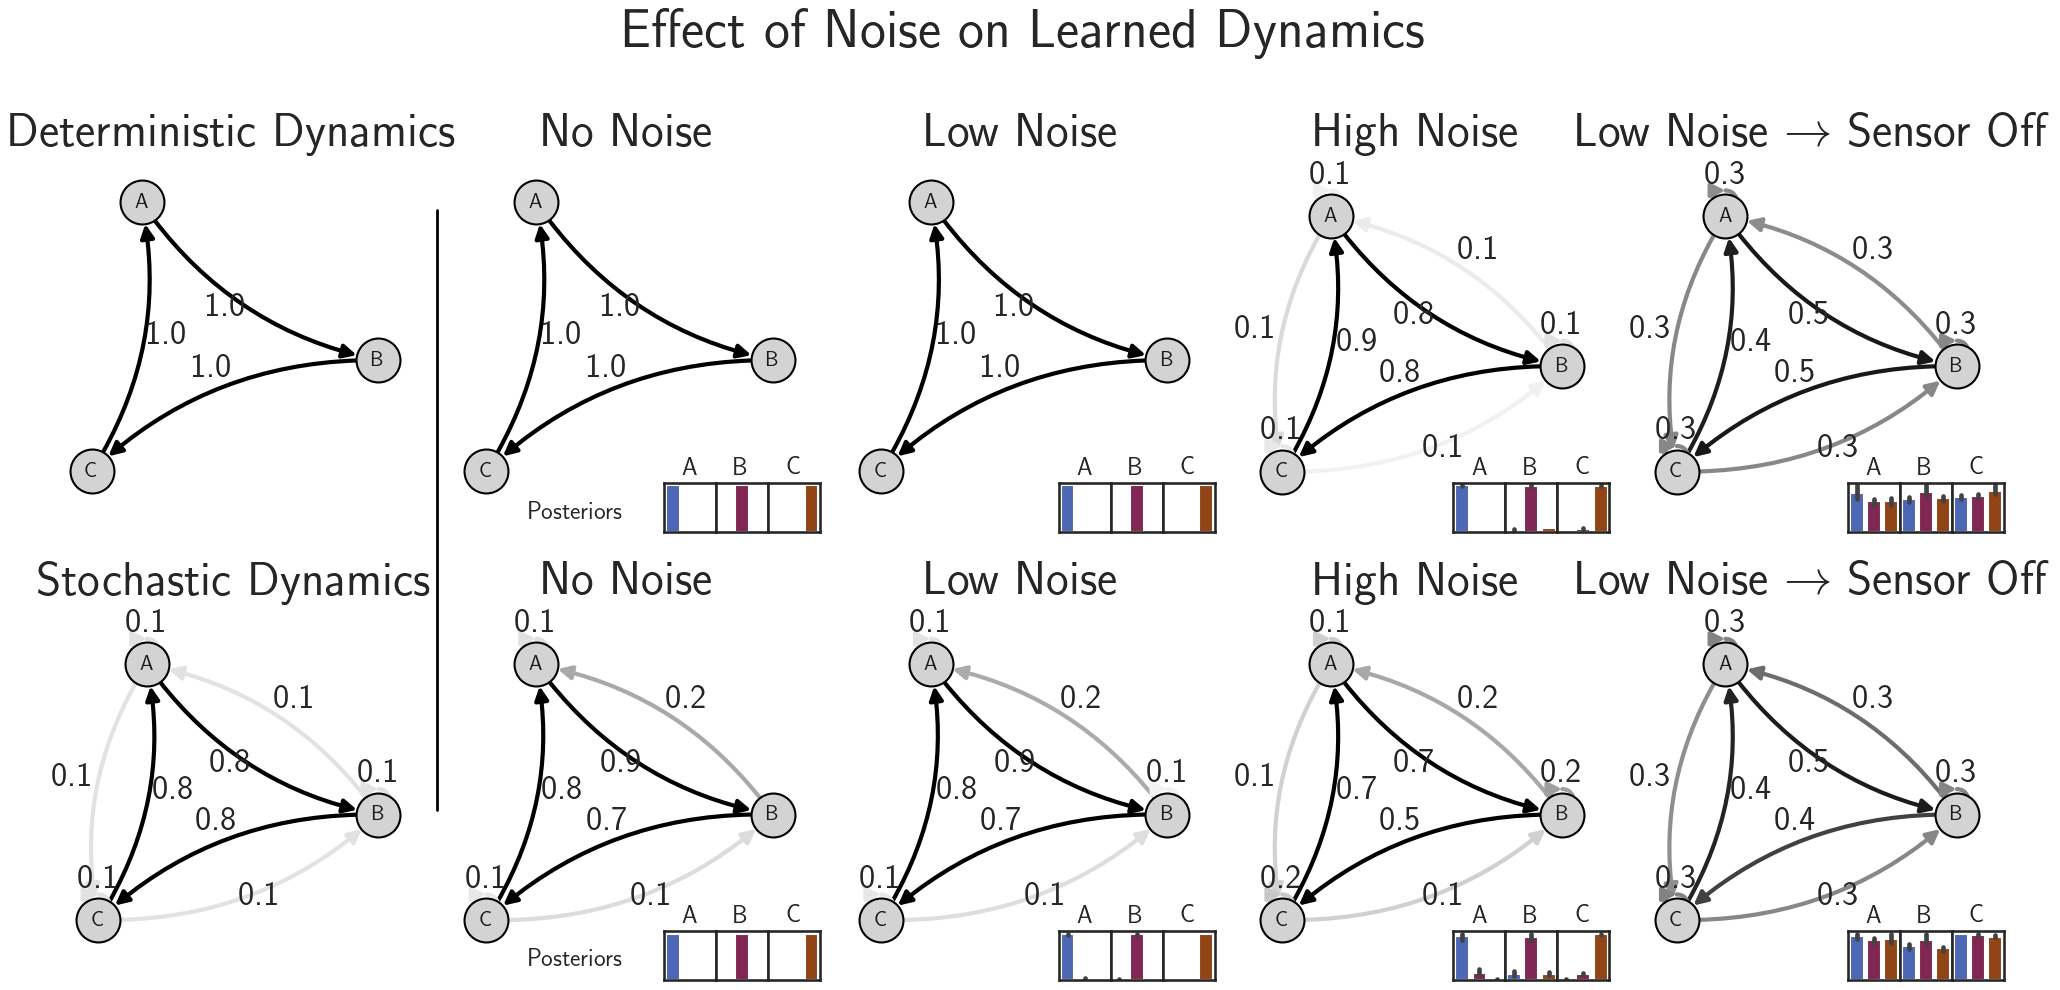

In [6]:
sns.set(style='white', context='talk')
ibm_palette = [ '#648fff', '#dc267f', '#fe6100', '#ffb000', '#785ef0', '#8be04e', '#009e73', '#56b4e9']
ibm_palette_darker = ['#3b5fc4','#8f1953','#a63f00','#a86f00','#4a37b8', '#8be04e', '#009e73', '#56b4e9']
sns.set_palette(ibm_palette_darker)

fig, ax = plt.subplots(2, 5, figsize=(5*4, 5*2))
fig.add_artist(plt.Line2D([0.205, 0.205], [0.2, 0.8], transform=fig.transFigure, color='black', linewidth=2, linestyle='-'))

i_half = len(deterministic_sequence)//2

thr = 0.05
states = ['A', 'B', 'C']
G_layout = nx.DiGraph()
G_layout.add_nodes_from(states)
pos = nx.spring_layout(G_layout, seed=42)

true_model = SLIM(dim, model_name='Deterministic Dynamics')
true_model.W = np.array([[0., 1., 0.],
                         [0., 0., 1.],
                         [1., 0., 0.]])
viz.create_digraph(true_model, states, ax[0][0], thr=thr)

viz.create_digraph(low, states, ax[0][1], thr=thr)
plot_inset(ax[0][1], low, deterministic_sequence)

viz.create_digraph(low_sensor_noise, states, ax[0][2], thr=thr)
plot_inset(ax[0][2], low_sensor_noise, deterministic_sequence)

viz.create_digraph(high_sensor_noise, states, ax[0][3], thr=thr)
plot_inset(ax[0][3], high_sensor_noise, deterministic_sequence)

viz.create_digraph(low_then_sensor_off, states, ax[0][4], thr=thr)
plot_inset(ax[0][4], low_then_sensor_off, deterministic_sequence)

####################### stochastic deterministic_sequence

true_model = SLIM(dim, model_name='Stochastic Dynamics')
true_model.W = stochastic_dynamics_matrix
viz.create_digraph(true_model, states, ax[1][0], thr=thr)

viz.create_digraph(low_process_noise, states, ax[1][1], thr=thr)
plot_inset(ax[1][1], low_process_noise, stochastic_sequence)

viz.create_digraph(low_process_and_sensor_noise, states, ax[1][2], thr=thr)
plot_inset(ax[1][2], low_process_and_sensor_noise, stochastic_sequence)

viz.create_digraph(high_process_and_sensor_noise, states, ax[1][3], thr=thr)
plot_inset(ax[1][3], high_process_and_sensor_noise, stochastic_sequence)

viz.create_digraph(low_process_then_sensor_off, states, ax[1][4], thr=thr)
plot_inset(ax[1][4], low_process_then_sensor_off, stochastic_sequence)

ax[1][1].text(-.4,-1.2, 'Posteriors')
ax[0][1].text(-.4,-1.2, 'Posteriors')

# Noise Effect
plt.suptitle(r'Effect of Noise on Learned Dynamics', fontweight='bold', fontsize=40, y=1.0)
plt.tight_layout()
plt.savefig('./results/learned_dynamics_with_posteriors.png', transparent=True, bbox_inches='tight')
plt.show()

###########################################

sns.set_palette(ibm_palette)


---

# Learning Nonstationary World Dynamics

---

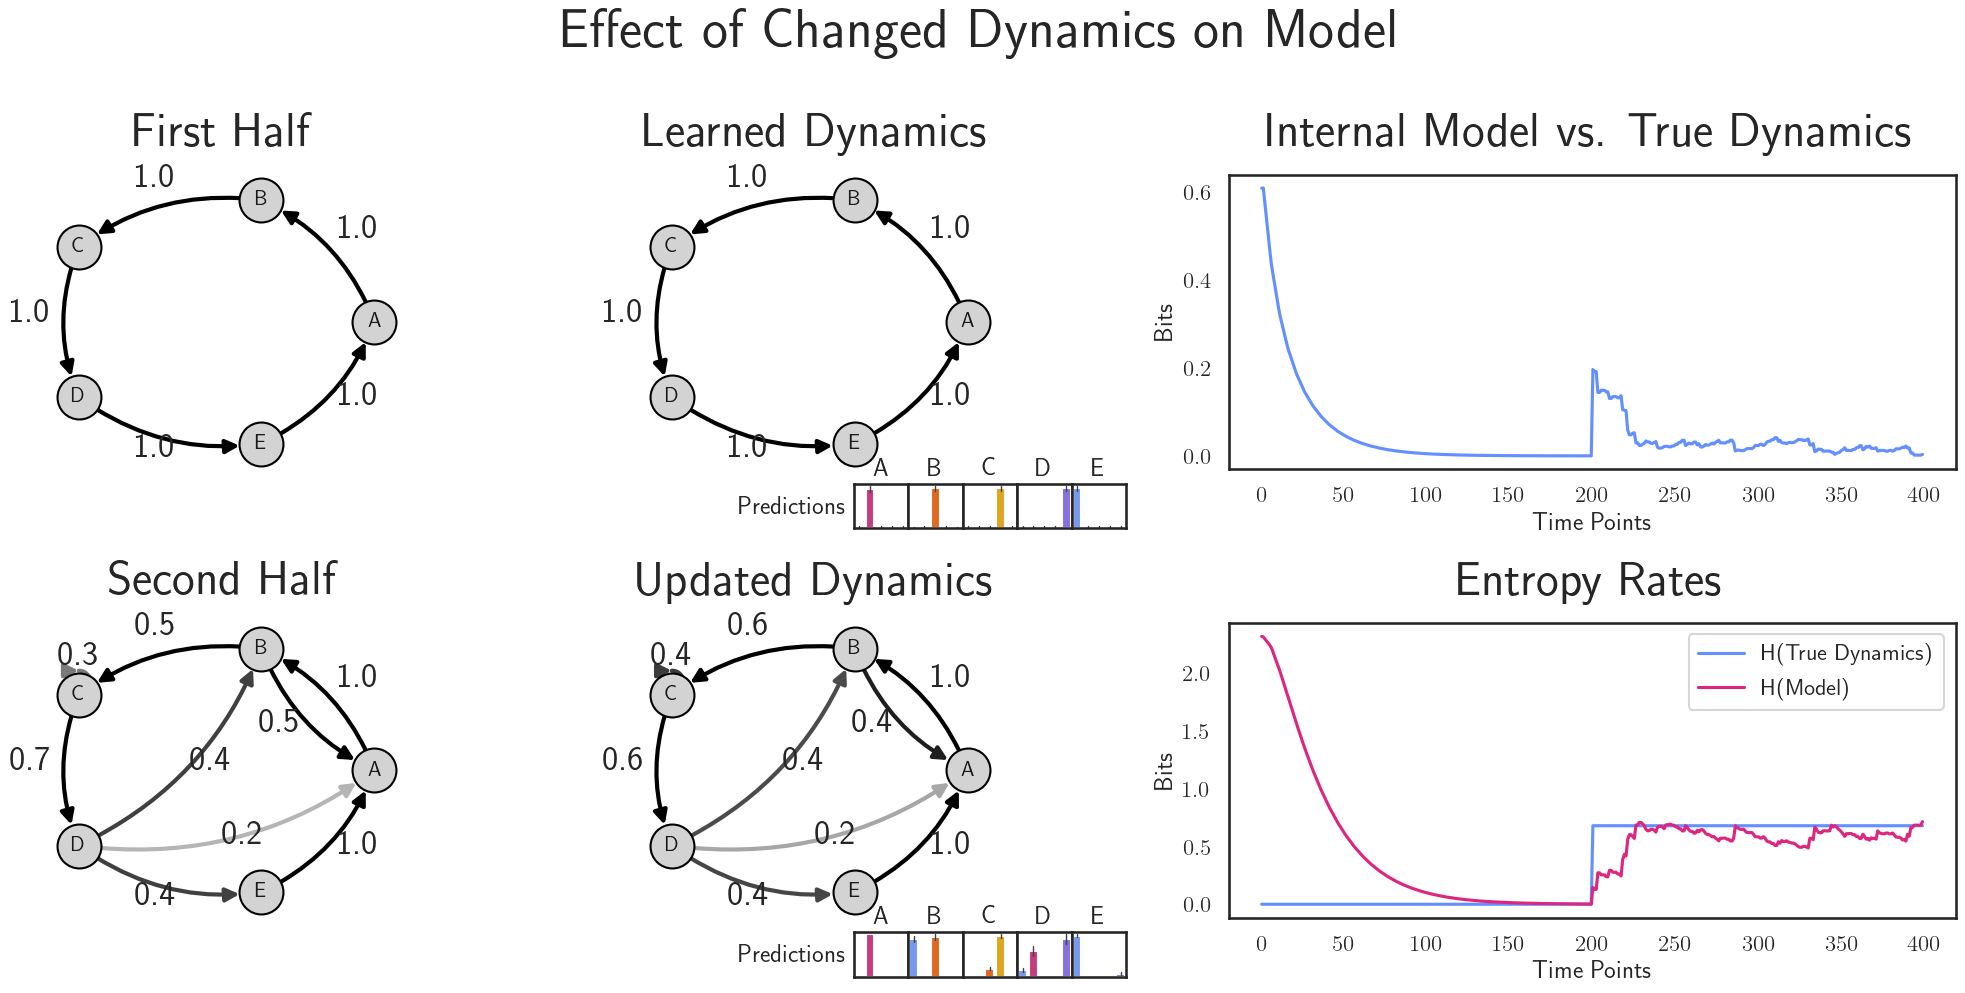

In [7]:
model = SLIM(dim=5, sensor=np.eye(5))
lr = 0.2

# fig, ax = plt.subplots(2, 3, figsize=(15,10))
fig = plt.figure(figsize=(20, 10))

gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 2], height_ratios=[1, 1])
ax1 = plt.subplot(gs[0, 0])
ax2 = plt.subplot(gs[0, 1])
ax3 = plt.subplot(gs[1, 0])
ax4 = plt.subplot(gs[1, 1])
ax5 = plt.subplot(gs[0, 2])
ax6 = plt.subplot(gs[1, 2])

G_layout = nx.DiGraph()
states = ['A', 'B', 'C', 'D', 'E']
G_layout.add_nodes_from(states)
pos = nx.circular_layout(G_layout)


dynamics_first_half = np.array([[.0, 1., .0, .0, .0],
                                [.0, 0., 1., .0, .0],
                                [.0, 0., .0, 1., .0],
                                [.0, 0., .0, .0, 1.],
                                [1., 0., .0, .0, .0]])

dynamics_second_half = np.array([[.0, 1., .0, .0, .0],
                                [.5, .0, .5, .0, .0],
                                [.0, 0., .3, 0.7, .0],
                                [.2, .4, .0, 0., .4],
                                [1., 0., .0, .0, .0]])

# sample
sequence_first_half = [0]
for _ in range(200-1):
    dist = dynamics_first_half[sequence_first_half[-1]]
    sequence_first_half.append(np.random.choice(range(5), p=dist))
sequence_second_half = [sequence_first_half[-1]]
for _ in range(200-1):
    dist = dynamics_second_half[sequence_second_half[-1]]
    sequence_second_half.append(np.random.choice(range(5), p=dist))

########################### first half #################################################

placeholder = SLIM(dim=5, model_name='First Half')
placeholder.W = dynamics_first_half
viz.create_digraph(placeholder, states, ax1, thr=thr, pos=pos)

# model.fit(sequence_first_half, learning_rate=lr)
jsds = []
H_rates = []
for item in sequence_first_half:
    model.step(model.observe(item, feed_observations=False), learning_rate=lr)
    del model.x_hat_hist[-1]
    model.predict()
    jsds.append(jsd_avg(dynamics_first_half, model.W))
    H_rates.append(entropy_rate(model.W))
    
model.model_name = 'Learned Dynamics'
viz.create_digraph(model, states, ax2, thr=thr, pos=pos)

##############
axins = ax2.inset_axes([0.1+0.5, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[np.array(sequence_first_half)==0], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('A')
axins = ax2.inset_axes([0.1+0.65, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[np.array(sequence_first_half)==1], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('B')
axins = ax2.inset_axes([0.1+0.8, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[np.array(sequence_first_half)==2], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('C')
axins = ax2.inset_axes([0.1+0.95, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[np.array(sequence_first_half)==3], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('D')
axins = ax2.inset_axes([0.1+1.1, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[np.array(sequence_first_half)==4], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('E')

########################### second half #################################################

placeholder = SLIM(dim=5, model_name='Second Half')
placeholder.W = dynamics_second_half
viz.create_digraph(placeholder, states, ax3, thr=thr, pos=pos)

model.model_name = 'Updated Dynamics'
# model.fit(sequence_second_half, learning_rate=lr)
for item in sequence_second_half:
    model.step(model.observe(item, feed_observations=False), learning_rate=lr)
    del model.x_hat_hist[-1]
    model.predict()
    jsds.append(jsd_avg(dynamics_second_half, model.W))
    H_rates.append(entropy_rate(model.W))

viz.create_digraph(model, states, ax4, thr=thr, pos=pos)

# jsds
ax5.set_title('Internal Model vs. True Dynamics', fontweight='bold', fontsize=35, pad=20)
sns.lineplot(jsds, ax=ax5)
ax5.set_xlabel('Time Points')
ax5.set_ylabel('Bits')

# entropies

entropies_gt = np.concatenate([[entropy_rate(dynamics_first_half)]*len(sequence_first_half), [entropy_rate(dynamics_second_half)]*len(sequence_second_half)])

sns.lineplot(entropies_gt, ax=ax6, label='H(True Dynamics)')
sns.lineplot(H_rates, ax=ax6, label='H(Model)')
ax6.set_xlabel('Time Points')
ax6.set_ylabel('Bits')
ax6.set_title('Entropy Rates', fontweight='bold', fontsize=35, pad=20)


##############
i_half = len(sequence_first_half)
axins = ax4.inset_axes([0.1+0.5, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[i_half:][np.array(sequence_second_half)==0], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('A')
axins = ax4.inset_axes([0.1+0.65, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[i_half:][np.array(sequence_second_half)==1], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('B')
axins = ax4.inset_axes([0.1+0.8, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[i_half:][np.array(sequence_second_half)==2], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('C')
axins = ax4.inset_axes([0.1+0.95, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[i_half:][np.array(sequence_second_half)==3], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('D')
axins = ax4.inset_axes([0.1+1.1, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[i_half:][np.array(sequence_second_half)==4], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('E')

ax2.text(-.4,-1.5, 'Predictions')
ax4.text(-.4,-1.5, 'Predictions')

plt.suptitle(r'Effect of Changed Dynamics on Model', fontweight='bold', fontsize=40, y=1.0)
plt.tight_layout()
plt.savefig('./results/updated_dynamics_with_predictions.png', transparent=True, bbox_inches='tight')

plt.tight_layout()
plt.show()

---

# Local-Global Paradigm

---

### Define Sequence

In [8]:
sequence = [0,0,0,1]*50

# inject 3 local-standard global-deviants
sequence[60+99] = 0
sequence[60+119] = 0
sequence[60+131] = 0

### Train Hierarchical Model

In [9]:
state_dim = 2
sensor = np.eye(state_dim)

learning_rate = 0.01

# model definitions
local_level = SLIM(order=1, track_dyn=True, verbose=False, feedback_from_levels=[3], dim=state_dim, sensor=np.eye(state_dim), model_name='1st Order Dynamics')
global_level = SLIM(order=3, track_dyn=True, verbose=False, feedforward_from_levels=[1], dim=state_dim, sensor=np.eye(state_dim), model_name='3rd Order Dynamics')

x_hat_global_level = np.ones(state_dim)/state_dim  # set first feedback as uninformative (uniform)

loop = tqdm(sequence)
for x in loop:
    y = local_level.observe(x)
    x_tilde_local_level = local_level.step(y, fb_prediction=x_hat_global_level, learning_rate=learning_rate)
    x_hat_global_level = global_level.step(x_tilde_local_level, learning_rate=learning_rate)



  0%|          | 0/200 [00:00<?, ?it/s]

	 Warning, model <3rd Order Dynamics> got no measurement, initializing with a uniform distribution.


### PLot Hierarchical Prediction Errors

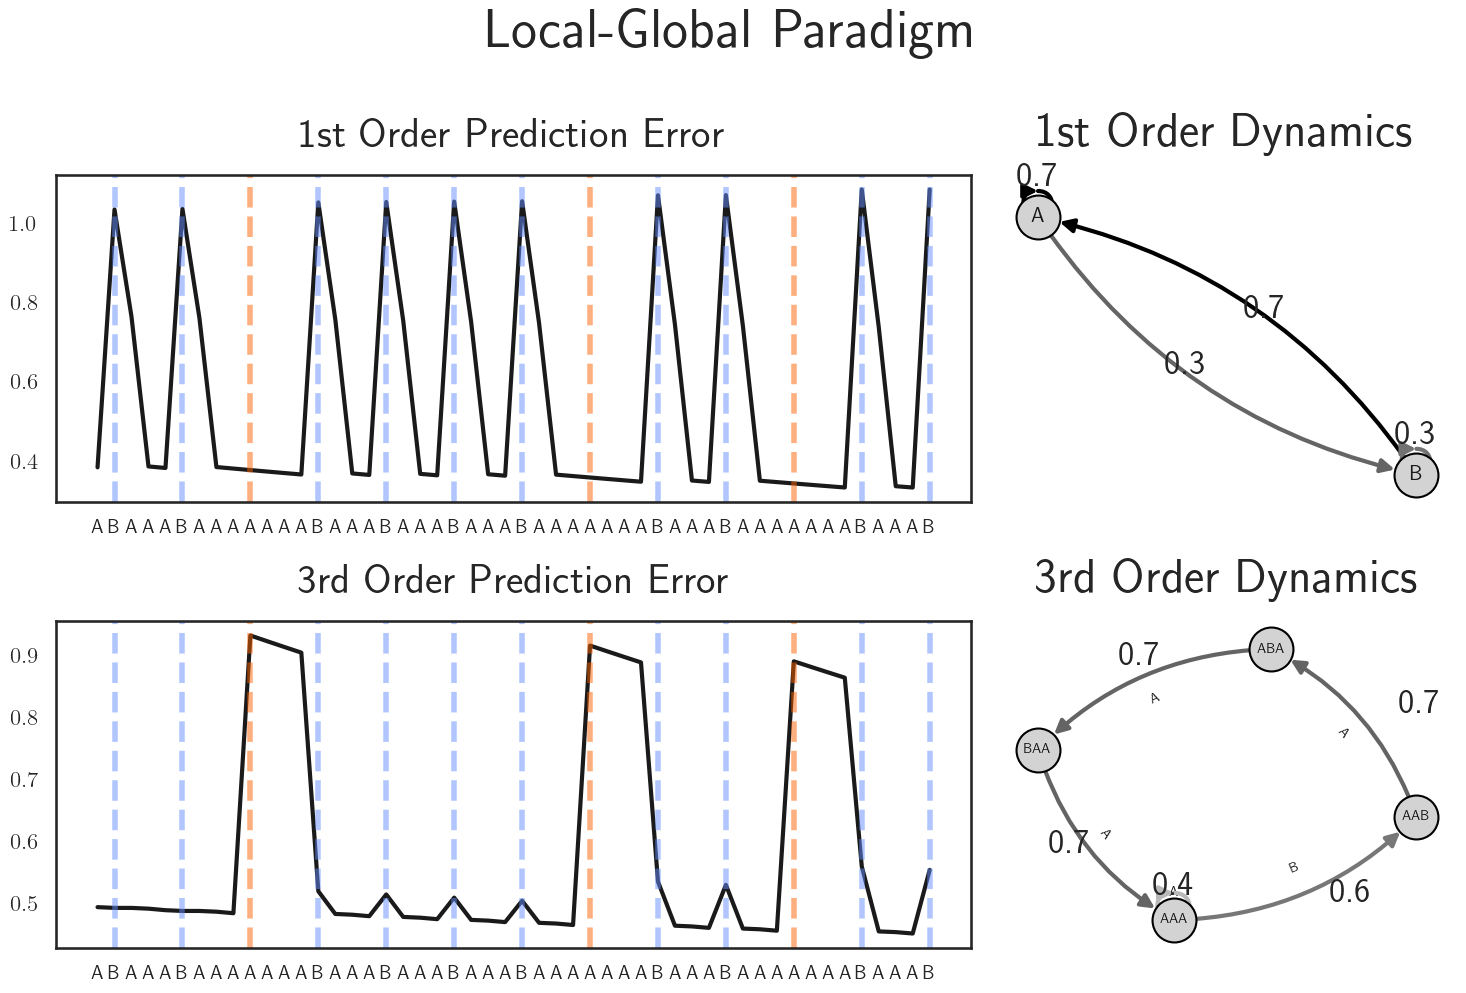

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(5*3, 5*2))

thr = 0.05

gs = gridspec.GridSpec(2, 2, width_ratios=[2, 1], height_ratios=[1, 1])
ax1 = plt.subplot(gs[0, 0])
ax2 = plt.subplot(gs[0, 1])
ax3 = plt.subplot(gs[1, 0])
ax4 = plt.subplot(gs[1, 1])

states = ['A', 'B']

last = 50

sns.lineplot(np.array(local_level.state_prediction_error)[-last:], ax=ax1, c='k', linewidth=3)
ax1.set_title('1st Order Prediction Error', fontweight='bold', fontsize=30, pad=20)
ax1.set_xticks(np.arange(last), [states[elem] for elem in sequence[-last:]], fontweight='bold', fontsize=14)
        
sns.lineplot(np.array(global_level.state_prediction_error)[-last:], ax=ax3, c='k', linewidth=3)
ax3.set_title('3rd Order Prediction Error', fontweight='bold', fontsize=30, pad=20)
ax3.set_xticks(np.arange(last), [states[elem] for idx,elem in enumerate(sequence[-last:])], fontweight='bold', fontsize=14)

local_errors = [0 if elem==0 else 1 for elem in sequence[-last:]]
for idx, err in enumerate(local_errors):
    if err:
        ax1.axvline(idx, 0, ymax=1, c='#648fff', linestyle='--', alpha=0.5, linewidth=4)
        ax3.axvline(idx, 0, ymax=1, c='#648fff', linestyle='--', alpha=0.5, linewidth=4)

global_errors = [1 if idx>2 and sum(sequence[-last:][idx-3:idx+4])==0 else 0 for idx,elem in enumerate(sequence[-last:])]
for idx, err in enumerate(global_errors):
    if err:
        ax1.axvline(idx, 0, ymax=1, c='#fe6100', linestyle='--', alpha=0.5, linewidth=4)
        ax3.axvline(idx, 0, ymax=1, c='#fe6100', linestyle='--', alpha=0.5, linewidth=4)


################################################################################################################
        
viz.create_digraph(model=local_level, states=['A', 'B'], axis=ax2, thr=thr)

################################################################################################################

G = nx.DiGraph()
edges = [
    ('AAA', 'AAA', 'A'),
    ('AAA', 'AAB', 'B'),
    ('AAB', 'ABA', 'A'),
    ('ABA', 'BAA', 'A'),
    ('BAA', 'AAA', 'A'),
]

edge_labels_code = {
    ('AAA', 'AAA'): 'A',
    ('AAA', 'AAB'): 'B',
    ('AAB', 'ABA'): 'A',
    ('ABA', 'BAA'): 'A',
    ('BAA', 'AAA'): 'A'
}

weights = [global_level.W[0][0], global_level.W[0][1], global_level.W[1][0], global_level.W[2][0], global_level.W[2][0]]

for idx, (u, v, label) in enumerate(edges):
    G.add_edge(u, v, label=label, weight=weights[idx])
    
pos = nx.spring_layout(G)

# edge_labels = nx.get_edge_attributes(G, 'label')
edge_labels = nx.get_edge_attributes(G, 'weight')
norm = mcolors.Normalize(vmin=0., vmax=1.)
cmap = plt.cm.Greys
edge_labels = nx.get_edge_attributes(G, 'weight')
edge_colors = [cmap(norm(G[u][v]['weight'])) for u, v in G.edges()]

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_code)

nx.draw(G, pos, with_labels=True, node_size=1000, node_color='lightgray', font_size=10, font_weight='bold',
        arrows=True, edgecolors='black', edge_color=edge_colors, connectionstyle='arc3,rad=0.2', arrowsize=20, width=3)

for (u, v), w in edge_labels.items():
    if w > thr:
        if u != v:
            x1, y1 = pos[u]
            x2, y2 = pos[v]
            mx, my = (x1 + x2) / 2, (y1 + y2) / 2
            dx, dy = x2 - x1, y2 - y1
            perp_offset = -0.3  # Increase for more distance from edge
            norm = np.sqrt(dx**2 + dy**2)
            ox, oy = -dy / norm * perp_offset, dx / norm * perp_offset
            ax4.text(mx + ox, my + oy, f"{w:.1f}", fontsize=25, bbox=dict(facecolor='none', edgecolor='none')) #, alpha=0.0))
        else:
            x, y = pos[u]
            ax4.text(x, y + 0.25, f"{w:.1f}", fontsize=25, va='center', ha='center', bbox=dict(facecolor='none', edgecolor='none')) #, alpha=0.6))
for node in states:
    if G.has_edge(node, node):
        x, y = pos[node]
        offset = 0.2
        ax4.add_patch(FancyArrowPatch((x + offset, y + offset), (x + offset, y + offset), connectionstyle="arc3,rad=0.5",  arrowstyle='->', arrowsize=20, mutation_scale=20, color='black', lw=1.5))
        
ax4.axis('off')
ax4.set_title(global_level.model_name, fontweight='bold', fontsize=35, pad=20)

for ax in ax.ravel():
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)                   
                   
plt.suptitle('Local-Global Paradigm', fontweight='bold', fontsize=40, y=1.0)
plt.tight_layout()
plt.savefig('./results/local_global_paradigm.png', transparent=True)
plt.show()


---